# 📱 PhonePe AI-Powered Fraud Detection

## An AI/ML-Based Approach to Detecting Fraudulent Digital Payment Transactions

**Student Name:** Ayushi, Angel, Arshita, Arpita, Ankita, Aniketa, Anchit
**Course:** BBA FinTech & AI  
**Company:** PhonePe  
**Industry:** FinTech / Digital Payments  

---

### 🔍 Project Overview

Digital payments have become an important part of everyday financial transactions. As the volume of digital payments increases, the risk of fraudulent transactions also increases. Fraud can occur through social engineering, phishing, identity theft, fraudulent accounts, suspicious beneficiaries, unauthorized transactions, malicious devices and misuse of payment systems.

This project presents an **AI/ML-based fraud detection approach** for a digital payment platform such as PhonePe. The objective is to analyse transaction-related information and identify patterns that may indicate fraudulent activity.

The project demonstrates how Machine Learning can be used to:

- Identify suspicious transactions
- Learn patterns from historical transaction data
- Classify transactions according to their risk
- Support faster fraud detection
- Reduce manual monitoring
- Improve customer protection

> **Important:** This is an academic ML project. The model developed in this notebook is a demonstration and does not represent PhonePe's proprietary internal fraud-detection model.

# 2. Problem Statement

## 🎯 Business Problem

**How can a digital payment platform identify potentially fraudulent transactions while allowing genuine customers to complete their payments smoothly?**

The challenge is to distinguish between:

- ✅ Genuine transactions
- ⚠️ Suspicious transactions
- 🚨 Potentially fraudulent transactions

A fraud-detection system should analyse transaction patterns and identify unusual or risky behaviour.

The system should ideally provide a fast and data-driven risk assessment so that appropriate action can be taken.

### Possible Actions

| Risk Level | Possible Action |
|------------|-----------------|
| Low Risk | Approve transaction |
| Medium Risk | Warn / Verify |
| High Risk | Block / Investigate |

The exact risk-scoring formula used by PhonePe is proprietary. Therefore, this notebook uses an **academic representation** of the fraud-detection process.

# 3. Project Objectives

The main objectives of this project are:

- Detect potentially fraudulent transactions.
- Explore transaction patterns and features.
- Build a Machine Learning classification model.
- Evaluate the model using suitable metrics.
- Understand how AI/ML can support real-time fraud detection.

1. Install/import libraries

In [20]:
# Install required libraries
!pip -q install pandas numpy scikit-learn matplotlib seaborn

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

2. Create a sample digital-payment dataset

Since you don't have PhonePe's private transaction dataset, do not claim that this is real PhonePe data. This creates an educational/synthetic dataset for your prototype.

# 4. Dataset

The dataset contains transaction-related information that can help identify fraudulent behaviour.

Key information may include:

- Transaction amount
- Transaction frequency
- Device or location details
- User behaviour
- Fraud/legitimate transaction label

The dataset will be explored and prepared before model training.

In [21]:
# Reproducible results
np.random.seed(42)

n = 10000

data = pd.DataFrame({
    "transaction_amount": np.random.exponential(1500, n),
    "transactions_last_24h": np.random.poisson(4, n),
    "account_age_days": np.random.randint(1, 2000, n),
    "new_device": np.random.binomial(1, 0.15, n),
    "new_recipient": np.random.binomial(1, 0.20, n),
    "location_change": np.random.binomial(1, 0.10, n),
    "failed_attempts": np.random.poisson(0.5, n),
    "night_transaction": np.random.binomial(1, 0.25, n),
    "previous_fraud_reports": np.random.binomial(1, 0.05, n)
})

# Create a fraud-risk score for the synthetic dataset
risk_score = (
    0.0008 * data["transaction_amount"] +
    0.15 * data["transactions_last_24h"] +
    1.2 * data["new_device"] +
    1.0 * data["new_recipient"] +
    1.3 * data["location_change"] +
    0.8 * data["failed_attempts"] +
    0.5 * data["night_transaction"] +
    2.0 * data["previous_fraud_reports"] -
    0.0003 * data["account_age_days"]
)

# Convert risk score into probability
probability = 1 / (1 + np.exp(-risk_score + 4))

# Generate fraud label
data["is_fraud"] = np.random.binomial(1, probability)

data.head()

,transaction_amount,transactions_last_24h,account_age_days,new_device,new_recipient,location_change,failed_attempts,night_transaction,previous_fraud_reports,is_fraud
0,703.902135,3,1043,0,0,0,2,1,0,0
1,4515.182146,2,1753,1,1,0,0,0,0,1
2,1975.118540,8,1117,0,0,0,0,1,0,0
3,1369.413831,0,1433,1,0,0,1,0,0,0
4,254.437306,2,1077,0,0,0,2,0,0,0


3. Check the dataset

In [22]:
print("Dataset shape:", data.shape)

print("\nFraud distribution:")
print(data["is_fraud"].value_counts())

print("\nFraud percentage:")
print(data["is_fraud"].mean() * 100)

Dataset shape: (10000, 10)

Fraud distribution:
is_fraud
0    7436
1    2564
Name: count, dtype: int64

Fraud percentage:
25.64


4. Visualize fraud vs genuine transactions

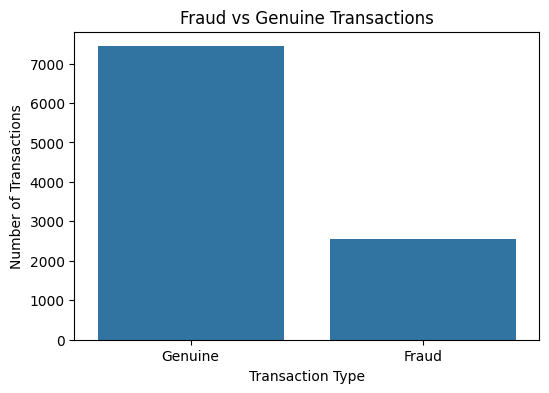

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=data,
    x="is_fraud"
)

plt.title("Fraud vs Genuine Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.xticks(
    [0, 1],
    ["Genuine", "Fraud"]
)

plt.show()

# 4. Data Cleaning

Before applying Machine Learning, the dataset needs to be checked and cleaned.

In this step, we will:

- Check for missing values
- Check for duplicate records
- Check the data types
- Check for unusual or invalid values

The purpose of data cleaning is to make sure that the dataset is reliable and suitable for further analysis.

In [24]:
# Check missing values
print("Missing Values:")
print(data.isnull().sum())

# Check duplicate records
print("\nDuplicate Records:", data.duplicated().sum())

# Check data types
print("\nData Types:")
print(data.dtypes)

# Check basic statistics
print("\nDataset Summary:")
display(data.describe())

Missing Values:
transaction_amount        0
transactions_last_24h     0
account_age_days          0
new_device                0
new_recipient             0
location_change           0
failed_attempts           0
night_transaction         0
previous_fraud_reports    0
is_fraud                  0
dtype: int64

Duplicate Records: 0

Data Types:
transaction_amount        float64
transactions_last_24h       int64
account_age_days            int64
new_device                  int64
new_recipient               int64
location_change             int64
failed_attempts             int64
night_transaction           int64
previous_fraud_reports      int64
is_fraud                    int64
dtype: object

Dataset Summary:


,transaction_amount,transactions_last_24h,account_age_days,new_device,new_recipient,location_change,failed_attempts,night_transaction,previous_fraud_reports,is_fraud
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1466.248432,4.009500,1003.547300,0.151000,0.198600,0.093100,0.505000,0.248600,0.050500,0.256400
std,1461.607060,2.003749,576.302564,0.358067,0.398966,0.290587,0.709525,0.432223,0.218985,0.436667
min,0.017452,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,424.198759,3.000000,505.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1017.472438,4.000000,1008.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2020.647445,5.000000,1497.250000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
max,12258.668397,13.000000,1999.000000,1.000000,1.000000,1.000000,5.000000,1.000000,1.000000,1.000000


# 5. Data Preprocessing

After cleaning the dataset, the data must be prepared for Machine Learning.

In this step, we will:

- Separate input features (X) and target (y)
- Identify the fraud column as the target variable
- Prepare the data for model training
- Split the dataset into training and testing sets

This allows the Machine Learning model to learn from the training data and later test its performance on unseen data.

In [25]:
# Separate features and target
X = data.drop("is_fraud", axis=1)
y = data["is_fraud"]

print("Features (X):")
display(X.head())

print("\nTarget (y):")
display(y.head())

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features (X):


,transaction_amount,transactions_last_24h,account_age_days,new_device,new_recipient,location_change,failed_attempts,night_transaction,previous_fraud_reports
0,703.902135,3,1043,0,0,0,2,1,0
1,4515.182146,2,1753,1,1,0,0,0,0
2,1975.118540,8,1117,0,0,0,0,1,0
3,1369.413831,0,1433,1,0,0,1,0,0
4,254.437306,2,1077,0,0,0,2,0,0



Target (y):


,is_fraud
0,0
1,1
2,0
3,0
4,0



Feature shape: (10000, 9)
Target shape: (10000,)


5. Prepare data for ML

In [26]:
X = data.drop("is_fraud", axis=1)
y = data["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 8000
Testing samples: 2000


6. Train the Random Forest model

In [27]:
model = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


7. Make predictions


In [28]:
y_pred = model.predict(X_test)

y_probability = model.predict_proba(X_test)[:, 1]

print("Predictions completed!")


Predictions completed!


8. evaluate the model

In [29]:
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_probability)

print("Accuracy:", round(accuracy, 4))
print("ROC-AUC:", round(auc, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8005
ROC-AUC: 0.8101

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1487
           1       0.62      0.57      0.59       513

    accuracy                           0.80      2000
   macro avg       0.74      0.73      0.73      2000
weighted avg       0.80      0.80      0.80      2000



9. Confusion Matrix

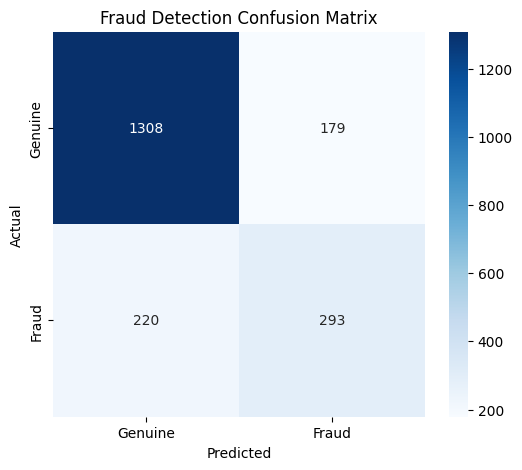

In [30]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Genuine", "Fraud"],
    yticklabels=["Genuine", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Fraud Detection Confusion Matrix")

plt.show()

10. See which factors are important

This is useful for your AI/ML Solution slide.

In [31]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                  Feature  Importance
0      transaction_amount    0.469124
2        account_age_days    0.169664
1   transactions_last_24h    0.087319
6         failed_attempts    0.081738
8  previous_fraud_reports    0.052179
4           new_recipient    0.040117
5         location_change    0.038406
3              new_device    0.036731
7       night_transaction    0.024723


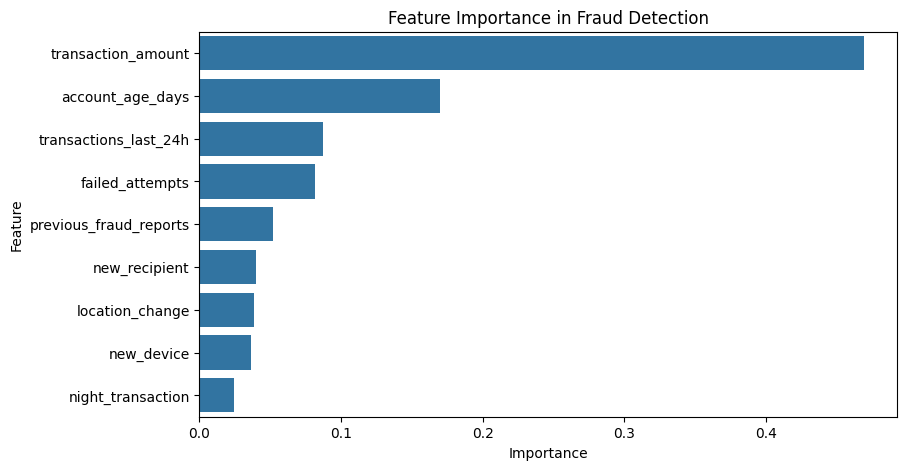

In [32]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance in Fraud Detection")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

11. Create the PhonePe-style risk scoring system

This is the important part for your presentation.

In [33]:
def fraud_decision(fraud_probability):

    if fraud_probability < 0.30:
        return "LOW RISK - APPROVE"

    elif fraud_probability < 0.70:
        return "MEDIUM RISK - VERIFY"

    else:
        return "HIGH RISK - BLOCK / INVESTIGATE"

12. Test a new transaction

In [34]:
new_transaction = pd.DataFrame({
    "transaction_amount": [25000],
    "transactions_last_24h": [12],
    "account_age_days": [50],
    "new_device": [1],
    "new_recipient": [1],
    "location_change": [1],
    "failed_attempts": [3],
    "night_transaction": [1],
    "previous_fraud_reports": [0]
})

probability = model.predict_proba(new_transaction)[0][1]

decision = fraud_decision(probability)

print("Fraud Probability:", round(probability * 100, 2), "%")
print("Decision:", decision)

Fraud Probability: 82.0 %
Decision: HIGH RISK - BLOCK / INVESTIGATE


13. Try a normal transaction

In [35]:
normal_transaction = pd.DataFrame({
    "transaction_amount": [500],
    "transactions_last_24h": [2],
    "account_age_days": [800],
    "new_device": [0],
    "new_recipient": [0],
    "location_change": [0],
    "failed_attempts": [0],
    "night_transaction": [0],
    "previous_fraud_reports": [0]
})

probability = model.predict_proba(normal_transaction)[0][1]

decision = fraud_decision(probability)

print("Fraud Probability:", round(probability * 100, 2), "%")
print("Decision:", decision)

Fraud Probability: 9.65 %
Decision: LOW RISK - APPROVE


14. Make a simple prediction function

Then you can demonstrate the model live in your viva.

In [36]:
def check_transaction(
    amount,
    transactions_24h,
    account_age,
    new_device,
    new_recipient,
    location_change,
    failed_attempts,
    night_transaction,
    previous_fraud
):

    transaction = pd.DataFrame({
        "transaction_amount": [amount],
        "transactions_last_24h": [transactions_24h],
        "account_age_days": [account_age],
        "new_device": [new_device],
        "new_recipient": [new_recipient],
        "location_change": [location_change],
        "failed_attempts": [failed_attempts],
        "night_transaction": [night_transaction],
        "previous_fraud_reports": [previous_fraud]
    })

    probability = model.predict_proba(transaction)[0][1]

    decision = fraud_decision(probability)

    print("================================")
    print("PHONEPE FRAUD DETECTION DEMO")
    print("================================")
    print("Transaction Amount: ₹", amount)
    print("Fraud Probability:", round(probability * 100, 2), "%")
    print("Decision:", decision)

In [37]:
check_transaction(
    amount=30000,
    transactions_24h=15,
    account_age=20,
    new_device=1,
    new_recipient=1,
    location_change=1,
    failed_attempts=4,
    night_transaction=1,
    previous_fraud=0
)

PHONEPE FRAUD DETECTION DEMO
Transaction Amount: ₹ 30000
Fraud Probability: 81.33 %
Decision: HIGH RISK - BLOCK / INVESTIGATE


In [38]:
check_transaction(
    amount=800,
    transactions_24h=2,
    account_age=900,
    new_device=0,
    new_recipient=0,
    location_change=0,
    failed_attempts=0,
    night_transaction=0,
    previous_fraud=0
)

PHONEPE FRAUD DETECTION DEMO
Transaction Amount: ₹ 800
Fraud Probability: 9.68 %
Decision: LOW RISK - APPROVE


# 11. Conclusion

This project demonstrates how AI and Machine Learning can be applied to digital payment fraud detection.

The overall process is:

**Data → Preprocessing → ML Model → Prediction → Evaluation → Fraud Detection**

The goal is to improve security, reduce fraud and support safer digital payments.